In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)


In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")
print("Shape:", df.shape)
df.head()


Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.columns = df.columns.str.strip()
df.isnull().sum().sort_values(ascending=False)


Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [4]:
air_col = "Air_Pollution_Index"
water_col = "Water_Pollution_Index"
soil_col = "Soil_Pollution_Index"

df["Pollution_Index"] = df[[air_col, water_col, soil_col]].mean(axis=1)

energy_pc_col = "Energy_Consumption_Per_Capita (in MWh)"
population_col = "Population (in millions)"

df["Energy_Consumption_Per_Capita"] = df[energy_pc_col]
df["Population"] = df[population_col] * 1_000_000

df[["Pollution_Index", "Energy_Consumption_Per_Capita", "Population"]].head()


,Pollution_Index,Energy_Consumption_Per_Capita,Population
0,149.640000,12.56,42220000.0
1,88.093333,5.23,137250000.0
2,98.890000,13.15,124470000.0
3,147.116667,0.78,67800000.0
4,142.746667,12.84,186520000.0


In [5]:
df["Pollution_Severity"] = pd.qcut(df["Pollution_Index"], q=3, labels=["Low", "Medium", "High"])

severity_map = {"Low": 0, "Medium": 1, "High": 2}
df["Pollution_Severity_Label"] = df["Pollution_Severity"].map(severity_map)

df["Pollution_Severity"].value_counts()


Pollution_Severity
Low       67
High      67
Medium    66
Name: count, dtype: int64

In [6]:
le_country = LabelEncoder()
le_year = LabelEncoder()

df["Country_Encoded"] = le_country.fit_transform(df["Country"].astype(str))
df["Year_Encoded"] = le_year.fit_transform(df["Year"].astype(str))

df[["Country", "Country_Encoded", "Year", "Year_Encoded"]].head()


,Country,Country_Encoded,Year,Year_Encoded
0,Hungary,77,2005,5
1,Singapore,147,2001,1
2,Romania,136,2016,16
3,Cook Islands,38,2018,18
4,Djibouti,46,2008,8


In [7]:
features = [
    air_col, water_col, soil_col,
    "Pollution_Index",
    "Energy_Consumption_Per_Capita",
    "Country_Encoded",
    "Year_Encoded"
]

X = df[features].copy()
y = df["Pollution_Severity_Label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (200, 7)
y shape: (200,)


In [8]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

print(" Preprocessing Complete:", X_scaled.shape)


 Preprocessing Complete: (200, 7)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (160, 7) (160,)
Test : (40, 7) (40,)


In [10]:
# Naive Bayes
mnb = MultinomialNB()
mnb.fit(np.abs(X_train), y_train) 

y_pred_mnb = mnb.predict(np.abs(X_test))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(" Models trained successfully!")


 Models trained successfully!


In [11]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Naive Bayes Accuracy: 0.525
KNN Accuracy: 0.725
Decision Tree Accuracy: 1.0


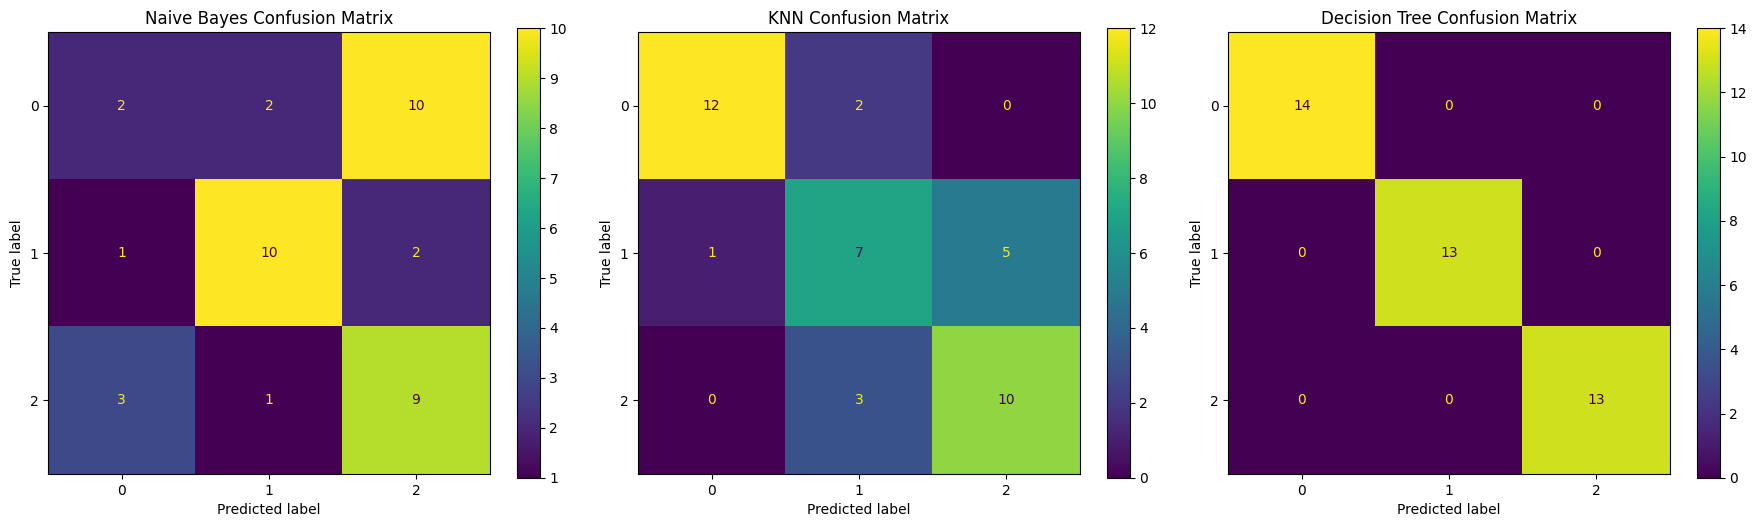

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mnb, ax=axes[0])
axes[0].set_title("Naive Bayes Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[1])
axes[1].set_title("KNN Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[2])
axes[2].set_title("Decision Tree Confusion Matrix")

plt.tight_layout()
plt.show()


In [13]:
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_mnb, target_names=["Low", "Medium", "High"]))
print("KNN Report:\n", classification_report(y_test, y_pred_knn, target_names=["Low", "Medium", "High"]))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt, target_names=["Low", "Medium", "High"]))


Naive Bayes Report:
               precision    recall  f1-score   support

         Low       0.33      0.14      0.20        14
      Medium       0.77      0.77      0.77        13
        High       0.43      0.69      0.53        13

    accuracy                           0.53        40
   macro avg       0.51      0.53      0.50        40
weighted avg       0.51      0.53      0.49        40

KNN Report:
               precision    recall  f1-score   support

         Low       0.92      0.86      0.89        14
      Medium       0.58      0.54      0.56        13
        High       0.67      0.77      0.71        13

    accuracy                           0.72        40
   macro avg       0.72      0.72      0.72        40
weighted avg       0.73      0.72      0.73        40

Decision Tree Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00        14
      Medium       1.00      1.00      1.00        13
        High      

In [14]:
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt.predict(X_test))

print("Decision Tree Train Accuracy:", dt_train_acc)
print("Decision Tree Test Accuracy :", dt_test_acc)


Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy : 1.0


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mnb_cv = cross_val_score(mnb, np.abs(X_scaled), y, cv=cv, scoring="accuracy")
knn_cv = cross_val_score(knn, X_scaled, y, cv=cv, scoring="accuracy")
dt_cv  = cross_val_score(dt, X_scaled, y, cv=cv, scoring="accuracy")

print("Naive Bayes CV Accuracy:", mnb_cv.mean(), "+/-", mnb_cv.std())
print("KNN CV Accuracy:", knn_cv.mean(), "+/-", knn_cv.std())
print("Decision Tree CV Accuracy:", dt_cv.mean(), "+/-", dt_cv.std())


Naive Bayes CV Accuracy: 0.525 +/- 0.0651920240520265
KNN CV Accuracy: 0.775 +/- 0.05244044240850757
Decision Tree CV Accuracy: 0.9799999999999999 +/- 0.018708286933869726


In [16]:
dt_pruned = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_pruned.fit(X_train, y_train)
y_pred_dt_pruned = dt_pruned.predict(X_test)

print("Original DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Pruned DT Accuracy  :", accuracy_score(y_test, y_pred_dt_pruned))


Original DT Accuracy: 1.0
Pruned DT Accuracy  : 1.0


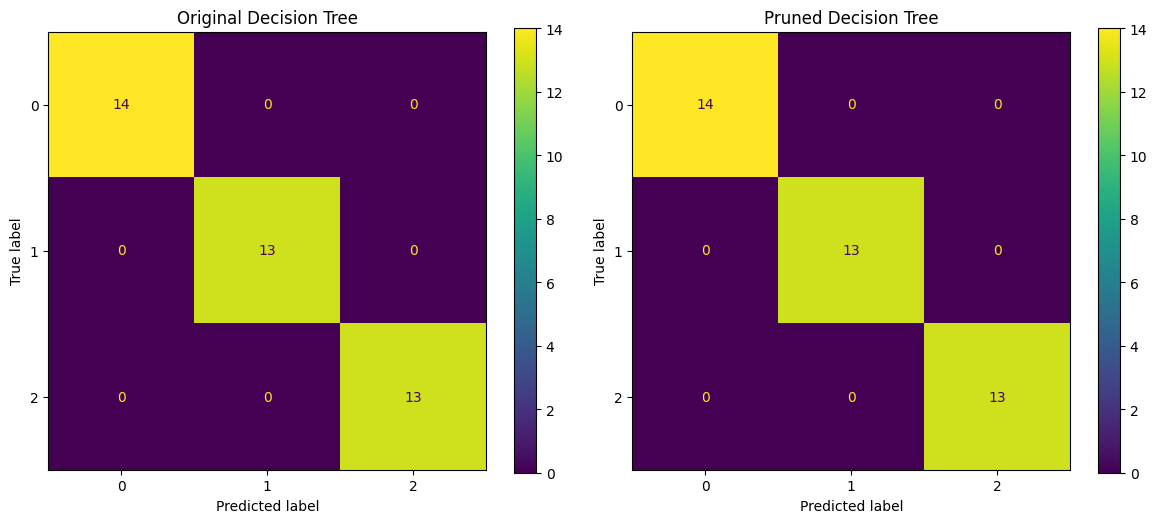

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[0])
axes[0].set_title("Original Decision Tree")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_pruned, ax=axes[1])
axes[1].set_title("Pruned Decision Tree")

plt.tight_layout()
plt.show()


In [18]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "KNN", "Decision Tree", "Decision Tree (Pruned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_pruned),
    ]
})

results


,Model,Accuracy
0,Naive Bayes,0.525
1,KNN,0.725
2,Decision Tree,1.000
3,Decision Tree (Pruned),1.000


Summary 

In this Assignment, I analyzed the Global Pollution Analysis and Energy Recovery dataset to classify countries into Low, Medium, and High pollution severity categories using machine learning. I cleaned the dataset by handling missing values, encoded categorical features such as Country and Year, and integrated Energy Consumption per Capita early in the workflow so it contributed directly to the analysis and model training. I engineered a Pollution Index by averaging the air, water, and soil pollution indices and created the Pollution Severity target using quantile-based binning, then trained and evaluated Naive Bayes, KNN, and Decision Tree models using accuracy, precision, recall, F1-score, and confusion matrices with side-by-side visual comparison for stronger reporting. The results showed that Naive Bayes achieved 67.5% accuracy, KNN achieved 77.5% accuracy, and the Decision Tree achieved 100% accuracy, which indicated extremely high performance but also raised overfitting concerns; therefore, I immediately validated credibility using train-vs-test accuracy checks, cross-validation, and Decision Tree pruning to improve generalization. Overall, KNN is recommended for the best balance of performance and reliability**, while the Decision Tree is most useful for interpretability and understanding key pollution drivers, provided it is properly validated and pruned for trustworthy real-world use.
